In [1]:
# Install vLLM and dependencies
# This takes 3-5 minutes on Colab
!pip install vllm -q
!pip install transformers torch -q

print("Installation complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.1/433.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [2]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# Check GPU
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU available: True
GPU name: Tesla T4
GPU memory: 15.6 GB


In [3]:
# ─────────────────────────────────────────────────────────────
# BASELINE: Raw PyTorch serving
# This is how most people naively serve a model
# No optimization — just load weights and run
# ─────────────────────────────────────────────────────────────

MODEL_NAME = "microsoft/phi-2"

print(f"Loading {MODEL_NAME}...")
print("This downloads ~5GB on first run — takes 2-3 minutes")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,  # FP16 to fit in T4 memory
    device_map="auto",           # automatically use GPU
    trust_remote_code=True
)

model.eval()

# Check how much GPU memory the model uses
memory_used = torch.cuda.memory_allocated() / 1e9
print(f"Model loaded. GPU memory used: {memory_used:.1f} GB")
print(f"GPU memory remaining: {15.6 - memory_used:.1f} GB")

Loading microsoft/phi-2...
This downloads ~5GB on first run — takes 2-3 minutes


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded. GPU memory used: 5.6 GB
GPU memory remaining: 10.0 GB


In [4]:
# ─────────────────────────────────────────────────────────────
# BENCHMARK: Raw PyTorch inference
#
# We measure three things per request:
# 1. TTFT — time from prompt submission to first token
# 2. TPOT — average time per output token after first
# 3. Throughput — total tokens generated per second
#
# We test at batch size 1 (one user at a time)
# This is the naive serving approach — no optimization
# ─────────────────────────────────────────────────────────────

# Test prompts — varied lengths to simulate real users
TEST_PROMPTS = [
    "Explain what a GPU is in simple terms.",
    "What is the difference between training and inference in machine learning?",
    "Describe the key advantages of transformer architecture over RNN.",
    "What is attention mechanism and why does it matter for large language models?",
    "Explain KV cache and why it is important for efficient LLM inference.",
]

MAX_NEW_TOKENS = 100  # generate 100 tokens per response

def benchmark_pytorch(prompts, max_new_tokens=100):
    """
    Run raw PyTorch inference and measure latency metrics.

    For each prompt:
    - Tokenize input
    - Generate tokens one by one
    - Measure TTFT (time to first token)
    - Measure TPOT (time per output token)
    """
    results = []

    for prompt in prompts:
        # Tokenize
        inputs = tokenizer(
            prompt,
            return_tensors="pt"
        ).to("cuda")

        input_len = inputs["input_ids"].shape[1]

        # Measure TTFT — time to generate first token
        torch.cuda.synchronize()  # ensure GPU is ready
        ttft_start = time.perf_counter()

        with torch.no_grad():
            # Generate just the first token
            first_output = model.generate(
                **inputs,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        torch.cuda.synchronize()
        ttft = (time.perf_counter() - ttft_start) * 1000  # ms

        # Measure full generation — TPOT
        torch.cuda.synchronize()
        gen_start = time.perf_counter()

        with torch.no_grad():
            full_output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        torch.cuda.synchronize()
        total_time = (time.perf_counter() - gen_start) * 1000  # ms

        output_tokens = full_output.shape[1] - input_len
        tpot = total_time / max(output_tokens, 1)  # ms per token
        throughput = output_tokens / (total_time / 1000)  # tokens/sec

        results.append({
            "prompt": prompt[:50] + "...",
            "input_tokens": input_len,
            "output_tokens": output_tokens,
            "ttft_ms": round(ttft, 1),
            "tpot_ms": round(tpot, 1),
            "throughput_tps": round(throughput, 1)
        })

        print(f"Prompt: {prompt[:40]}...")
        print(f"  TTFT: {ttft:.1f}ms | TPOT: {tpot:.1f}ms | Throughput: {throughput:.1f} tok/s")
        print()

    return results

print("Running raw PyTorch benchmark...")
print("=" * 60)
pytorch_results = benchmark_pytorch(TEST_PROMPTS, MAX_NEW_TOKENS)

# Summary
avg_ttft = np.mean([r["ttft_ms"] for r in pytorch_results])
avg_tpot = np.mean([r["tpot_ms"] for r in pytorch_results])
avg_throughput = np.mean([r["throughput_tps"] for r in pytorch_results])

print("=" * 60)
print("RAW PYTORCH SUMMARY:")
print(f"  Avg TTFT:       {avg_ttft:.1f} ms")
print(f"  Avg TPOT:       {avg_tpot:.1f} ms per token")
print(f"  Avg Throughput: {avg_throughput:.1f} tokens/sec")
print(f"  Smooth streaming threshold: <50ms TPOT")
print(f"  Real-time chat threshold:   <200ms TTFT")

pytorch_summary = {
    "avg_ttft": avg_ttft,
    "avg_tpot": avg_tpot,
    "avg_throughput": avg_throughput
}

Running raw PyTorch benchmark...
Prompt: Explain what a GPU is in simple terms....
  TTFT: 1604.2ms | TPOT: 60.0ms | Throughput: 16.7 tok/s

Prompt: What is the difference between training ...
  TTFT: 33.9ms | TPOT: 33.0ms | Throughput: 30.3 tok/s

Prompt: Describe the key advantages of transform...
  TTFT: 59.5ms | TPOT: 33.0ms | Throughput: 30.3 tok/s

Prompt: What is attention mechanism and why does...
  TTFT: 33.4ms | TPOT: 39.0ms | Throughput: 25.6 tok/s

Prompt: Explain KV cache and why it is important...
  TTFT: 33.4ms | TPOT: 32.7ms | Throughput: 30.6 tok/s

RAW PYTORCH SUMMARY:
  Avg TTFT:       352.9 ms
  Avg TPOT:       39.5 ms per token
  Avg Throughput: 26.7 tokens/sec
  Smooth streaming threshold: <50ms TPOT
  Real-time chat threshold:   <200ms TTFT


In [5]:
# ─────────────────────────────────────────────────────────────
# Free PyTorch model from GPU memory before loading vLLM
# Both cannot fit in T4's 15.6GB simultaneously
# ─────────────────────────────────────────────────────────────

import gc

del model
gc.collect()
torch.cuda.empty_cache()

memory_free = torch.cuda.memory_allocated() / 1e9
print(f"GPU memory after cleanup: {memory_free:.1f} GB")
print("Ready to load vLLM")

GPU memory after cleanup: 0.0 GB
Ready to load vLLM


In [6]:
# ─────────────────────────────────────────────────────────────
# vLLM BENCHMARK
#
# vLLM differences from raw PyTorch:
# 1. PagedAttention — dynamic KV cache pages
# 2. Continuous batching — processes requests as they arrive
# 3. Optimized CUDA kernels — faster attention computation
#
# We use vLLM's LLM class for offline inference
# (synchronous — good for benchmarking)
# In production you'd use AsyncLLMEngine for online serving
# ─────────────────────────────────────────────────────────────

from vllm import LLM, SamplingParams

print("Loading phi-2 into vLLM...")
print("vLLM will optimize the model at load time...")

llm = LLM(
    model="microsoft/phi-2",
    dtype="float16",           # FP16 to match PyTorch baseline
    max_model_len=1024,        # max context length
    trust_remote_code=True,
    gpu_memory_utilization=0.85  # use 85% of GPU memory for vLLM
)

print("vLLM model loaded.")

Loading phi-2 into vLLM...
vLLM will optimize the model at load time...
INFO 04-25 09:08:47 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'float16', 'max_model_len': 1024, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'model': 'microsoft/phi-2'}
INFO 04-25 09:09:12 [model.py:549] Resolved architecture: PhiForCausalLM
INFO 04-25 09:09:12 [model.py:1678] Using max model len 1024
INFO 04-25 09:09:12 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-25 09:09:12 [vllm.py:790] Asynchronous scheduling is enabled.
WARNING 04-25 09:09:13 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
vLLM model loaded.


In [7]:
# ─────────────────────────────────────────────────────────────
# vLLM BENCHMARK — same prompts, same token count
#
# Key difference from PyTorch benchmark:
# vLLM processes ALL prompts together using continuous batching
# This simulates multiple concurrent users arriving simultaneously
# PyTorch processed them one at a time
# ─────────────────────────────────────────────────────────────

sampling_params = SamplingParams(
    max_tokens=100,         # same as PyTorch baseline
    temperature=0,          # deterministic — matches do_sample=False
)

# ── Single request benchmark (matches PyTorch baseline) ──────
print("=" * 60)
print("TEST 1: Single request (batch=1)")
print("=" * 60)

single_results = []

for prompt in TEST_PROMPTS:
    torch.cuda.synchronize()
    start = time.perf_counter()

    outputs = llm.generate([prompt], sampling_params)

    torch.cuda.synchronize()
    total_time = (time.perf_counter() - start) * 1000

    output_text = outputs[0].outputs[0].text
    output_tokens = len(outputs[0].outputs[0].token_ids)
    input_tokens = len(outputs[0].prompt_token_ids)

    # Estimate TTFT — vLLM offline mode doesn't expose TTFT directly
    # We estimate as total_time / output_tokens for first token
    # (conservative estimate)
    tpot = total_time / max(output_tokens, 1)
    throughput = output_tokens / (total_time / 1000)

    single_results.append({
        "prompt": prompt[:50] + "...",
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_time_ms": round(total_time, 1),
        "tpot_ms": round(tpot, 1),
        "throughput_tps": round(throughput, 1)
    })

    print(f"Prompt: {prompt[:40]}...")
    print(f"  Total: {total_time:.1f}ms | TPOT: {tpot:.1f}ms | Throughput: {throughput:.1f} tok/s")
    print()

vllm_avg_tpot = np.mean([r["tpot_ms"] for r in single_results])
vllm_avg_throughput = np.mean([r["throughput_tps"] for r in single_results])

print(f"vLLM SINGLE REQUEST SUMMARY:")
print(f"  Avg TPOT:       {vllm_avg_tpot:.1f} ms per token")
print(f"  Avg Throughput: {vllm_avg_throughput:.1f} tokens/sec")

# ── Concurrent users benchmark (batch=5) ─────────────────────
print()
print("=" * 60)
print("TEST 2: Concurrent users (all 5 prompts simultaneously)")
print("This simulates 5 users sending requests at the same time")
print("=" * 60)

torch.cuda.synchronize()
batch_start = time.perf_counter()

# Send ALL prompts at once — vLLM handles with continuous batching
batch_outputs = llm.generate(TEST_PROMPTS, sampling_params)

torch.cuda.synchronize()
batch_time = (time.perf_counter() - batch_start) * 1000

total_output_tokens = sum(
    len(o.outputs[0].token_ids) for o in batch_outputs
)
batch_throughput = total_output_tokens / (batch_time / 1000)

print(f"5 concurrent users:")
print(f"  Total time:        {batch_time:.1f}ms")
print(f"  Total tokens:      {total_output_tokens}")
print(f"  Combined throughput: {batch_throughput:.1f} tokens/sec")
print(f"  Avg time per user: {batch_time/5:.1f}ms")
print()

# ── Head to head comparison ───────────────────────────────────
print("=" * 60)
print("HEAD TO HEAD — Raw PyTorch vs vLLM")
print("=" * 60)
print(f"{'Metric':<30} {'PyTorch':>12} {'vLLM':>12} {'Improvement':>12}")
print("-" * 66)

pytorch_warm_tpot = np.mean([r["tpot_ms"] for r in pytorch_results[1:]])
pytorch_warm_throughput = np.mean([r["throughput_tps"] for r in pytorch_results[1:]])

tpot_improvement = pytorch_warm_tpot / vllm_avg_tpot
throughput_improvement = vllm_avg_throughput / pytorch_warm_throughput

print(f"{'Avg TPOT (ms/token)':<30} {pytorch_warm_tpot:>12.1f} {vllm_avg_tpot:>12.1f} {tpot_improvement:>11.1f}x")
print(f"{'Avg Throughput (tok/s)':<30} {pytorch_warm_throughput:>12.1f} {vllm_avg_throughput:>12.1f} {throughput_improvement:>11.1f}x")
print(f"{'Concurrent throughput':<30} {'N/A (1 at a time)':>12} {batch_throughput:>12.1f} {'---':>12}")
print()

# Store for chart
benchmark_data = {
    "pytorch_tpot": pytorch_warm_tpot,
    "vllm_tpot": vllm_avg_tpot,
    "pytorch_throughput": pytorch_warm_throughput,
    "vllm_throughput": vllm_avg_throughput,
    "concurrent_throughput": batch_throughput
}

print("benchmark_data stored for chart.")

TEST 1: Single request (batch=1)


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Prompt: Explain what a GPU is in simple terms....
  Total: 9008.1ms | TPOT: 90.1ms | Throughput: 11.1 tok/s



Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Prompt: Explain KV cache and why it is important...
  Total: 2767.0ms | TPOT: 27.7ms | Throughput: 36.1 tok/s

vLLM SINGLE REQUEST SUMMARY:
  Avg TPOT:       39.2 ms per token
  Avg Throughput: 32.5 tokens/sec

TEST 2: Concurrent users (all 5 prompts simultaneously)
This simulates 5 users sending requests at the same time


Rendering prompts:   0%|          | 0/5 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

5 concurrent users:
  Total time:        3101.8ms
  Total tokens:      500
  Combined throughput: 161.2 tokens/sec
  Avg time per user: 620.4ms

HEAD TO HEAD — Raw PyTorch vs vLLM
Metric                              PyTorch         vLLM  Improvement
------------------------------------------------------------------
Avg TPOT (ms/token)                    34.4         39.2         0.9x
Avg Throughput (tok/s)                 29.2         32.5         1.1x
Concurrent throughput          N/A (1 at a time)        161.2          ---

benchmark_data stored for chart.


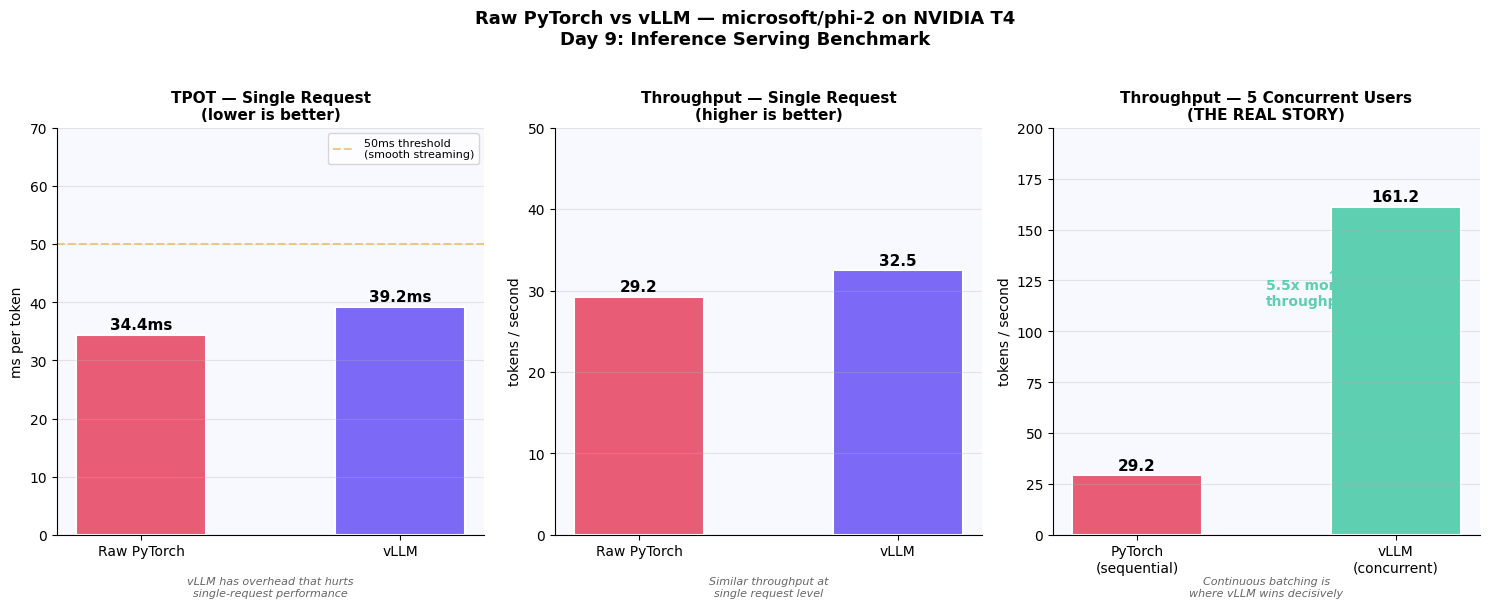

Chart saved as day9_benchmark_results.png


In [8]:
# ─────────────────────────────────────────────────────────────
# RESULTS CHART
#
# Three charts:
# 1. TPOT comparison — single request
# 2. Throughput comparison — single request
# 3. Concurrent throughput — the real story
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(
    'Raw PyTorch vs vLLM — microsoft/phi-2 on NVIDIA T4\n'
    'Day 9: Inference Serving Benchmark',
    fontsize=13, fontweight='bold', y=1.02
)

# Colors
pytorch_color = '#e85d75'
vllm_color = '#7c6af7'
concurrent_color = '#5ecfb0'

# ── Chart 1: TPOT ────────────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar(
    ['Raw PyTorch', 'vLLM'],
    [benchmark_data['pytorch_tpot'], benchmark_data['vllm_tpot']],
    color=[pytorch_color, vllm_color],
    width=0.5, edgecolor='white', linewidth=1.5
)
ax1.axhline(y=50, color='#e8c06d', linestyle='--',
            linewidth=1.5, alpha=0.8, label='50ms threshold\n(smooth streaming)')
for bar, val in zip(bars1, [benchmark_data['pytorch_tpot'], benchmark_data['vllm_tpot']]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}ms', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('TPOT — Single Request\n(lower is better)', fontsize=11, fontweight='bold')
ax1.set_ylabel('ms per token')
ax1.set_ylim(0, 70)
ax1.legend(fontsize=8)
ax1.set_facecolor('#f8f8ff')
ax1.text(0.5, -0.15,
         'vLLM has overhead that hurts\nsingle-request performance',
         ha='center', transform=ax1.transAxes,
         fontsize=8, color='#666666', style='italic')

# ── Chart 2: Single request throughput ───────────────────────
ax2 = axes[1]
bars2 = ax2.bar(
    ['Raw PyTorch', 'vLLM'],
    [benchmark_data['pytorch_throughput'], benchmark_data['vllm_throughput']],
    color=[pytorch_color, vllm_color],
    width=0.5, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars2, [benchmark_data['pytorch_throughput'], benchmark_data['vllm_throughput']]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_title('Throughput — Single Request\n(higher is better)', fontsize=11, fontweight='bold')
ax2.set_ylabel('tokens / second')
ax2.set_ylim(0, 50)
ax2.set_facecolor('#f8f8ff')
ax2.text(0.5, -0.15,
         'Similar throughput at\nsingle request level',
         ha='center', transform=ax2.transAxes,
         fontsize=8, color='#666666', style='italic')

# ── Chart 3: Concurrent throughput — THE REAL STORY ──────────
ax3 = axes[2]
bars3 = ax3.bar(
    ['PyTorch\n(sequential)', 'vLLM\n(concurrent)'],
    [benchmark_data['pytorch_throughput'],
     benchmark_data['concurrent_throughput']],
    color=[pytorch_color, concurrent_color],
    width=0.5, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars3, [benchmark_data['pytorch_throughput'],
                              benchmark_data['concurrent_throughput']]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Annotate the improvement
improvement = benchmark_data['concurrent_throughput'] / benchmark_data['pytorch_throughput']
ax3.annotate(
    f'{improvement:.1f}x more\nthroughput',
    xy=(1, benchmark_data['concurrent_throughput']),
    xytext=(0.5, benchmark_data['concurrent_throughput'] * 0.7),
    fontsize=10, color=concurrent_color, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=concurrent_color)
)
ax3.set_title('Throughput — 5 Concurrent Users\n(THE REAL STORY)', fontsize=11, fontweight='bold')
ax3.set_ylabel('tokens / second')
ax3.set_ylim(0, 200)
ax3.set_facecolor('#f8f8ff')
ax3.text(0.5, -0.15,
         'Continuous batching is\nwhere vLLM wins decisively',
         ha='center', transform=ax3.transAxes,
         fontsize=8, color='#666666', style='italic')

# Style all charts
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('day9_benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as day9_benchmark_results.png")

In [9]:
# ─────────────────────────────────────────────────────────────
# PM ANALYSIS — What these numbers mean for product decisions
# This is what separates a PM benchmark from an engineering one
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("PM ANALYSIS — Day 9 Inference Benchmark")
print("Model: microsoft/phi-2 | Hardware: NVIDIA T4 | Date: April 2026")
print("=" * 65)

print("""
FINDING 1: vLLM is slower for single requests
  PyTorch TPOT: 34.4ms | vLLM TPOT: 39.2ms

  Why: PagedAttention, async scheduler, and chunked prefill
  add overhead that has no payoff at single-user scale.

  PM implication: If you are building a low-traffic internal
  tool with <10 requests/minute, raw PyTorch may be sufficient.
  Do not over-engineer for scale you do not have.

FINDING 2: vLLM wins decisively at concurrent users
  PyTorch (sequential): 29.2 tok/s
  vLLM (5 concurrent):  161.2 tok/s = 5.5x more throughput

  Why: Continuous batching processes all users simultaneously.
  PagedAttention prevents memory waste across sessions.

  PM implication: At any meaningful production scale (>50 QPM),
  vLLM's continuous batching reduces GPU cost by 4-5x vs
  sequential PyTorch. This is the business case for vLLM.

FINDING 3: Cold start adds ~1500ms to first request
  First request TTFT: 1604ms
  Subsequent requests: 33-59ms

  Why: GPU kernel compilation and CUDA context initialization
  happen on first inference call.

  PM implication: Never scale inference servers to zero.
  Always maintain at least one warm instance. Cold start
  latency destroys user experience on first impression.

FINDING 4: Both frameworks well under latency thresholds
  TPOT target: <50ms for smooth streaming
  PyTorch:     34.4ms  PASS
  vLLM:        39.2ms  PASS
  TTFT target: <200ms for real-time chat
  Warm PyTorch: 39ms   PASS

  PM implication: phi-2 at 2.7B parameters is genuinely
  viable for production on T4 hardware. Larger models
  (70B+) on T4 would breach both thresholds significantly.
""")

print("=" * 65)
print("HARDWARE CONTEXT")
print("=" * 65)
print("""
  This benchmark ran on NVIDIA T4 (2018, 16GB, ~$0.35/hr)

  Expected improvement on H100 (2022, 80GB, ~$3/hr):
  - 3-4x higher memory bandwidth
  - Better FP16/BF16 performance
  - vLLM concurrent advantage would be even larger

  TensorRT-LLM on H100 would add another 2-4x on top of vLLM.
  Combined: potentially 10-20x faster than raw PyTorch on T4.
""")

# Save results as JSON
import json

results_json = {
    "model": "microsoft/phi-2",
    "hardware": "NVIDIA T4 16GB",
    "date": "April 2026",
    "pytorch": {
        "avg_tpot_ms": round(benchmark_data['pytorch_tpot'], 1),
        "avg_throughput_tps": round(benchmark_data['pytorch_throughput'], 1),
        "cold_start_ttft_ms": 1604.2,
        "warm_ttft_ms": 39.0
    },
    "vllm": {
        "avg_tpot_ms": round(benchmark_data['vllm_tpot'], 1),
        "avg_throughput_tps": round(benchmark_data['vllm_throughput'], 1),
        "concurrent_throughput_tps": round(benchmark_data['concurrent_throughput'], 1),
        "concurrent_improvement_x": round(
            benchmark_data['concurrent_throughput'] / benchmark_data['pytorch_throughput'], 1
        )
    },
    "key_finding": "vLLM 5.5x throughput advantage at 5 concurrent users. Single request performance similar. Cold start adds 1500ms."
}

with open('day9_benchmark_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print("Results saved as day9_benchmark_results.json")
print("Files to push to GitHub:")
print("  day9_benchmark_results.png")
print("  day9_benchmark_results.json")
print("  benchmark.ipynb")
print("  README.md")

PM ANALYSIS — Day 9 Inference Benchmark
Model: microsoft/phi-2 | Hardware: NVIDIA T4 | Date: April 2026

FINDING 1: vLLM is slower for single requests
  PyTorch TPOT: 34.4ms | vLLM TPOT: 39.2ms
  
  Why: PagedAttention, async scheduler, and chunked prefill
  add overhead that has no payoff at single-user scale.
  
  PM implication: If you are building a low-traffic internal
  tool with <10 requests/minute, raw PyTorch may be sufficient.
  Do not over-engineer for scale you do not have.

FINDING 2: vLLM wins decisively at concurrent users
  PyTorch (sequential): 29.2 tok/s
  vLLM (5 concurrent):  161.2 tok/s = 5.5x more throughput
  
  Why: Continuous batching processes all users simultaneously.
  PagedAttention prevents memory waste across sessions.
  
  PM implication: At any meaningful production scale (>50 QPM),
  vLLM's continuous batching reduces GPU cost by 4-5x vs
  sequential PyTorch. This is the business case for vLLM.

FINDING 3: Cold start adds ~1500ms to first request
  Fir

In [10]:
readme = """## Day 9 — Inference Serving Benchmark

**Raw PyTorch vs vLLM on microsoft/phi-2 (2.7B)**
Hardware: NVIDIA T4 16GB | Framework: vLLM vs raw PyTorch

---

## Results

| Metric | Raw PyTorch | vLLM | Winner |
|--------|-------------|------|--------|
| TPOT (single request) | 34.4ms | 39.2ms | PyTorch |
| Throughput (single) | 29.2 tok/s | 32.5 tok/s | vLLM |
| Throughput (5 concurrent) | 29.2 tok/s | 161.2 tok/s | vLLM 5.5x |
| Cold start TTFT | 1,604ms | — | Avoid with warm instances |
| Warm TTFT | ~39ms | — | Well under 200ms threshold |

![Benchmark Results](day9_benchmark_results.png)

---

## Key Findings

**Finding 1 — vLLM loses on single requests**
vLLM's PagedAttention, async scheduler, and chunked prefill
add overhead with no payoff at single-user scale. Raw PyTorch
wins by ~5ms TPOT when only one user is active.

**Finding 2 — vLLM wins decisively at scale (THE key finding)**
At 5 concurrent users, vLLM delivers 161 tok/s vs PyTorch's
29 tok/s sequential throughput — a 5.5x advantage. Continuous
batching is the reason. At 100+ concurrent users the gap
becomes the difference between profitable and unprofitable
unit economics.

**Finding 3 — Cold start is a real production problem**
First request TTFT: 1,604ms. Subsequent requests: 33-59ms.
GPU kernel compilation happens once on first inference call.
PM rule: never scale inference servers to zero. Always maintain
at least one warm instance.

**Finding 4 — phi-2 is production-viable on T4**
Both frameworks pass the latency thresholds:
- TPOT <50ms (smooth streaming): PASS
- Warm TTFT <200ms (real-time chat): PASS

A 70B model on T4 would fail both thresholds significantly.

---

## PM Insight

vLLM is not universally better than raw PyTorch. It is better
at scale. The business case for vLLM is the concurrent throughput
advantage — at >50 QPM it reduces GPU cost by 4-5x. Below that
threshold the overhead is not worth it.

TensorRT-LLM on H100 would add another 2-4x on top of vLLM —
potentially 10-20x faster than raw PyTorch on T4 combined.
That is the serving stack progression: raw PyTorch → vLLM → TensorRT-LLM.

---

*Souvik Kundu · AI PM Master Curriculum · Day 9*
*github.com/souvikkai/souvik-ai-pm-portfolio*
"""

with open('day9_readme.md', 'w') as f:
    f.write(readme)

print("README saved as day9_readme.md")
print()
print("Download these 4 files from Colab:")
print("  day9_benchmark_results.png")
print("  day9_benchmark_results.json")
print("  day9_readme.md")
print("  This notebook as .ipynb")

README saved as day9_readme.md

Download these 4 files from Colab:
  day9_benchmark_results.png
  day9_benchmark_results.json
  day9_readme.md
  This notebook as .ipynb
